# 03 — Moving Edge Responses (FAFB T4 Pathway)

Simulate moving light-edge stimuli across the photoreceptor array and
analyse direction-selective responses using **real FAFB connectome** data.

1. Build network (FAFB pathway)
2. Generate moving edge stimuli (12 directions)
3. Visualise stimuli
4. Simulate & plot per cell type
5. Direction selectivity analysis

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

from neuro_framework.models import (
    OpticLobeHHNetwork,
    load_or_build_cached_net,
    apply_postbuild_parameter_overrides,
    build_pathway_override_rules,
)
from neuro_framework.stimulus.visual import MovingEdgeStimulus

os.makedirs('../logs', exist_ok=True)
print(f'PyTorch {torch.__version__}')


PyTorch 2.2.0


## 1. Load Current Optic-Lobe Net

This notebook now reuses the current optic-lobe cached `FAFBMCNetwork`, then applies the same post-build override rules as the main optic-lobe notebook before generating moving-edge stimuli.


In [2]:
DATA_DIR = '../../mcHH/data/optic_lobe_right'
MORPH_PKG_DIR = '../../mcHH/data/optic_lobe_type_packages_v1'
ION_RULES = '../data/ion_channel_rules.csv'
SYN_RULES = '../data/synapse_rules.csv'
NT_ION_RULES = None
ROOT_ION_OVERRIDES = None

DT = 0.1
NCOMP = 2
MIN_SYN_COUNT = 3
MORPH_PROGRESS_EVERY = 5000

R16_ELEAK_SHIFT_MV = -10.0
R16_VTH_SHIFT_MV = 8.0
R16_TARGET_VTH_SHIFTS_MV = {'L1': -4.0, 'L3': -4.0}
R16_TARGET_GS_GAINS = {'L1': 1.5, 'L3': 1.25}

CACHE_DIR = '../../mcHH/data/cache'
NET_CACHE_PATH = f'{CACHE_DIR}/optic_lobe_net_type_rules_v3.pt'
FORCE_REBUILD = False
SAVE_CACHE_AFTER_BUILD = True

cache_meta = {
    'data_dir': DATA_DIR,
    'morph_pkg_dir': MORPH_PKG_DIR,
    'ion_rules': ION_RULES,
    'syn_rules': SYN_RULES,
    'dt': DT,
    'ncomp': NCOMP,
    'min_syn_count': MIN_SYN_COUNT,
}

net, loaded_cache_meta, loaded_from_cache, build_elapsed = load_or_build_cached_net(
    cache_path=NET_CACHE_PATH,
    force_rebuild=FORCE_REBUILD,
    save_cache_after_build=SAVE_CACHE_AFTER_BUILD,
    cache_meta=cache_meta,
    data_dir=DATA_DIR,
    morphology_package_dir=MORPH_PKG_DIR,
    ion_rules_path=ION_RULES,
    syn_rules_path=SYN_RULES,
    nt_ion_rules_path=NT_ION_RULES,
    neuron_ion_overrides_path=ROOT_ION_OVERRIDES,
    dt=DT,
    ncomp=NCOMP,
    min_syn_count=MIN_SYN_COUNT,
    morphology_progress_every=MORPH_PROGRESS_EVERY,
)
neuron_override_rules, synapse_override_rules = build_pathway_override_rules(
    eLeak_shift_mV=R16_ELEAK_SHIFT_MV,
    v_th_shift_mV=R16_VTH_SHIFT_MV,
    target_v_th_shifts_mV=R16_TARGET_VTH_SHIFTS_MV,
    target_gs_gains=R16_TARGET_GS_GAINS,
)
net = apply_postbuild_parameter_overrides(
    net, neuron_rules=neuron_override_rules, synapse_rules=synapse_override_rules, reset_first=True
)
print('loaded_from_cache =', loaded_from_cache)
print(f'build_elapsed = {build_elapsed:.1f}s')
print(net)
n_photo = int(net.input_mask.sum().item())
photo_idx = torch.where(net.input_mask)[0].tolist()
print(f'Photoreceptors: {n_photo}')


OpticLobeHHNetwork(n_neurons=302, n_edges=678, n_photoreceptors=199, n_cell_types=14, trainable=5203)
Photoreceptors: 199


## 2. Generate Moving Edge Stimuli

Photoreceptor positions are inferred from the **columnar connectivity**
(R → L1/L3 mapping). Each L1/L3 neuron defines a column; R neurons sharing
the same target get the same position. This preserves the spatial offset
between Mi1 columns and Mi9 columns that drives T4 direction selectivity.

In [3]:
dt = DT
t_pre = 100.0
t_stim = 300.0
t_post = 100.0
T_ms = t_pre + t_stim + t_post
I_amp = 30.0  # μA/cm²

neurons_csv = DATA_DIR + '/neurons.csv'
connections_csv = DATA_DIR + '/connections.csv'

column_coords = OpticLobeHHNetwork.compute_retinotopic_coords(
    neurons_csv, connections_csv, min_syn_count=MIN_SYN_COUNT,
)
column_coords = column_coords - column_coords.mean(axis=0)
column_coords = column_coords / (column_coords.std() + 1e-8)

print(f'Column coords: {column_coords.shape}, span {np.ptp(column_coords[:,0]):.2f} x {np.ptp(column_coords[:,1]):.2f}')

edge_speed = 0.05
field_span = np.sqrt(np.ptp(column_coords[:,0])**2 + np.ptp(column_coords[:,1])**2)
print(f'Edge speed: {edge_speed}, crossing time: {field_span/edge_speed:.0f} ms')

angles = np.arange(0, 360, 30)
stimuli = {}
for angle in angles:
    stim = MovingEdgeStimulus(
        coords=column_coords, direction_deg=float(angle),
        speed=edge_speed, amplitude=1.0, background=0.0,
        t_start=0, t_end=T_ms, dt=dt,
    )
    stimuli[angle] = stim.as_batch_tensor() * I_amp

T_steps = stimuli[0].shape[1]
t = np.arange(T_steps) * dt
print(f'{T_ms:.0f} ms = {T_steps} steps, {len(angles)} directions')


Column coords: (199, 2), span 4.37 x 4.44
Edge speed: 0.05, crossing time: 125 ms
500 ms = 20000 steps, 12 directions


## 3. Visualise Stimuli

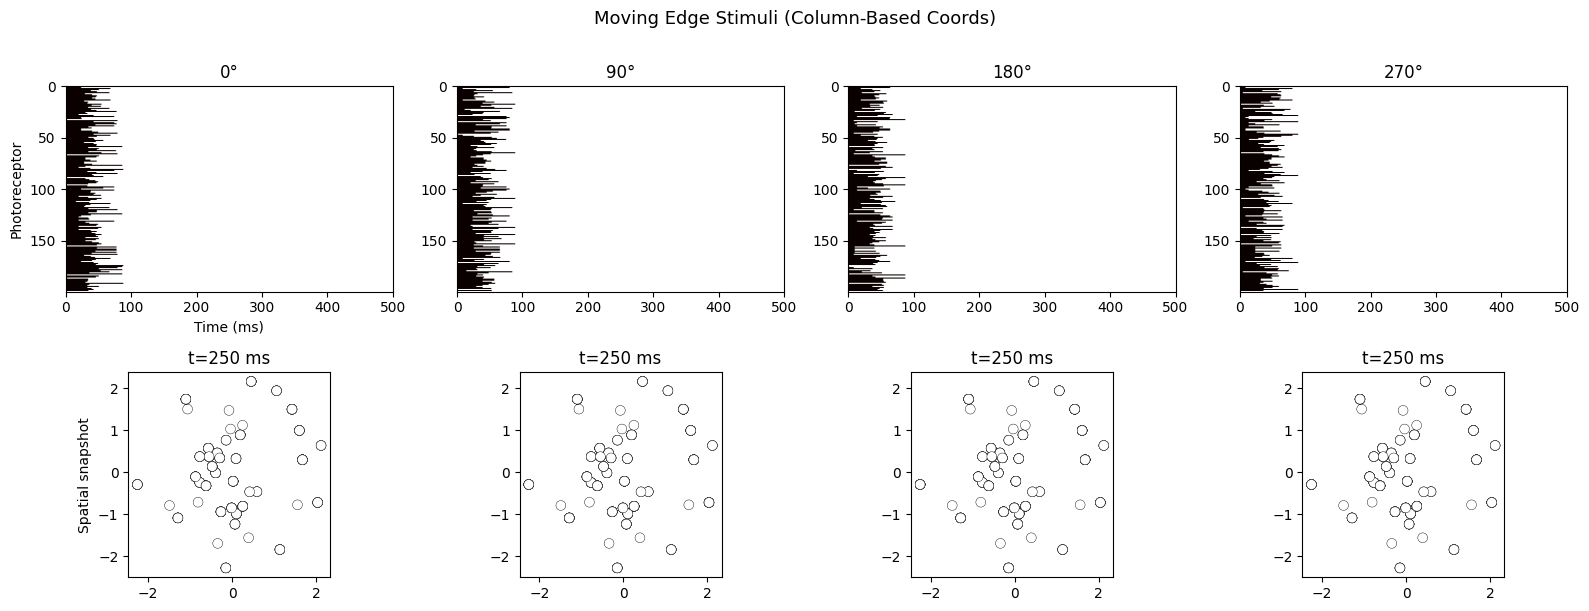

In [4]:
show_angles = [0, 90, 180, 270]
fig, axes = plt.subplots(2, 4, figsize=(16, 6))

for col, angle in enumerate(show_angles):
    x = stimuli[angle][0].numpy()
    axes[0, col].imshow(x.T, aspect='auto', cmap='hot',
                        extent=[0, T_ms, n_photo, 0])
    axes[0, col].set_title(f'{angle}°')
    if col == 0: axes[0, col].set_ylabel('Photoreceptor')

    t_snap = int((t_pre + t_stim / 2) / dt)
    axes[1, col].scatter(column_coords[:, 0], column_coords[:, 1],
                         c=x[t_snap], cmap='hot', vmin=0, vmax=I_amp,
                         s=50, edgecolors='k', linewidths=0.3)
    axes[1, col].set_aspect('equal')
    axes[1, col].set_title(f't={t_snap*dt:.0f} ms')

axes[0, 0].set_xlabel('Time (ms)')
axes[1, 0].set_ylabel('Spatial snapshot')
plt.suptitle('Moving Edge Stimuli (Column-Based Coords)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../logs/moving_edge_stimuli.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Simulate & Plot

In [5]:
responses = {}
for angle in angles:
    with torch.no_grad():
        V = net(stimuli[angle], dt=dt)
    responses[angle] = V

print(f'All {len(angles)} directions done.')

All 12 directions done.


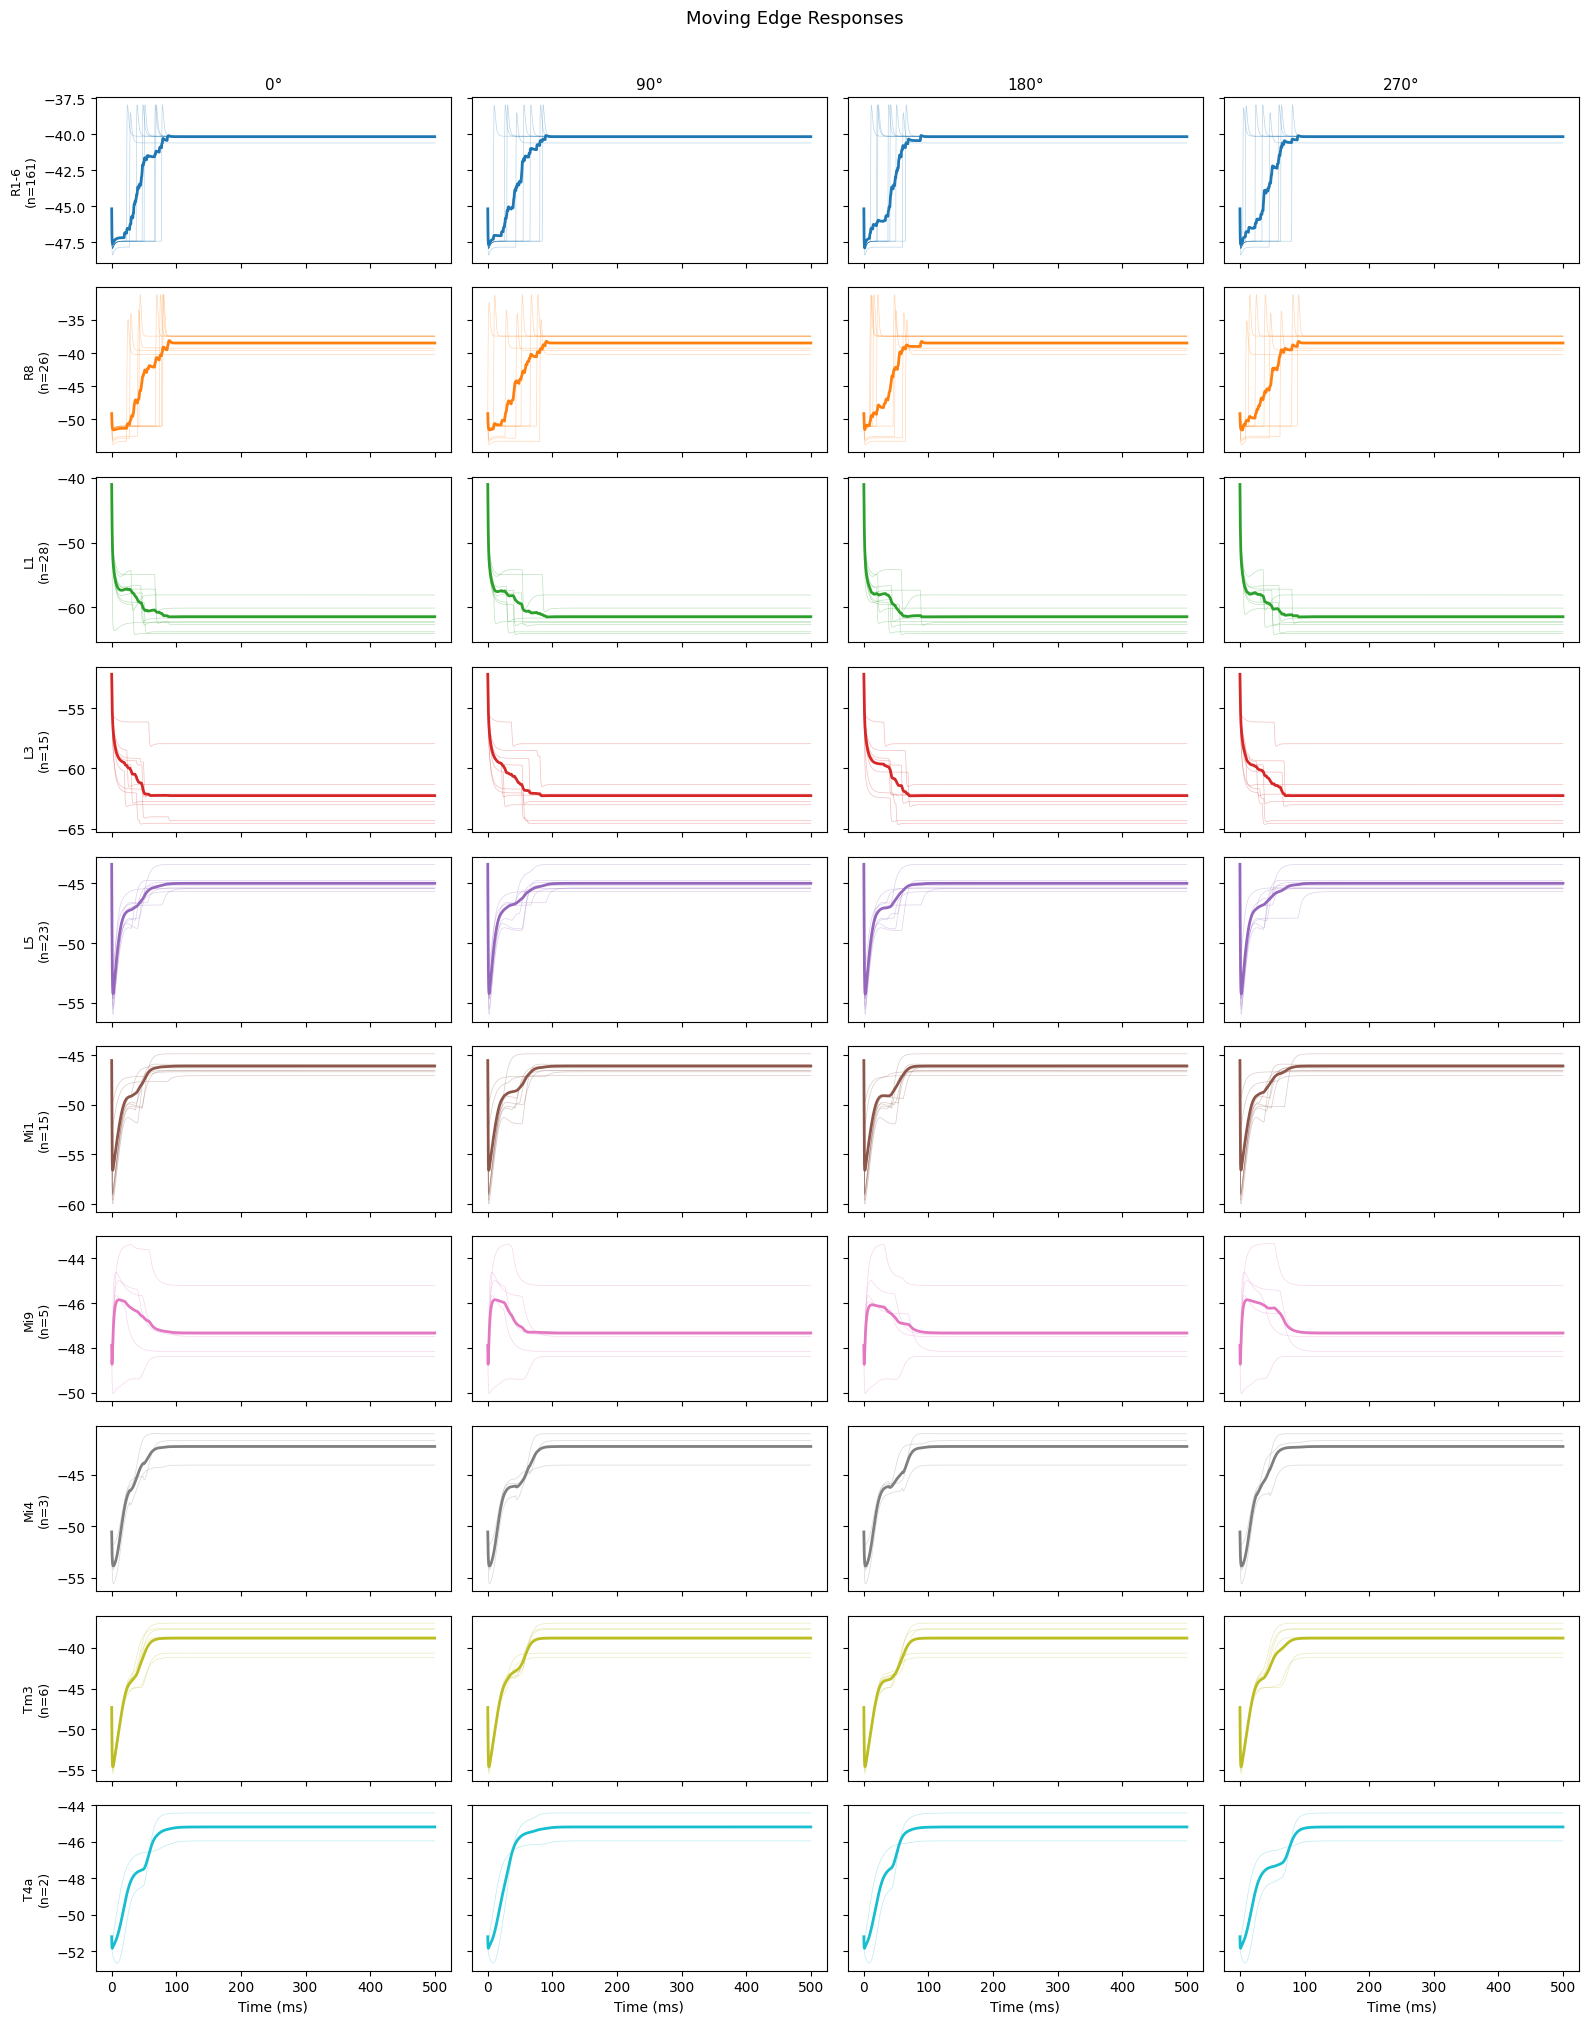

In [6]:
pathway = ['R1-6', 'R8', 'L1', 'L3', 'L5', 'Mi1', 'Mi9', 'Mi4', 'Tm3', 'T4a']
show_angles = [0, 90, 180, 270]

fig, axes = plt.subplots(len(pathway), len(show_angles),
                         figsize=(4 * len(show_angles), 2 * len(pathway)),
                         sharex=True, sharey='row')

for row, ct in enumerate(pathway):
    idx = net.get_indices_by_type(ct)
    if not idx: continue
    for col, angle in enumerate(show_angles):
        ax = axes[row, col]
        vs = responses[angle][0, :, idx].numpy()
        for j in range(min(8, len(idx))):
            ax.plot(t, vs[:, j], alpha=0.3, linewidth=0.5, color=f'C{row}')
        ax.plot(t, vs.mean(axis=1), color=f'C{row}', linewidth=2)
        if row == 0: ax.set_title(f'{angle}°', fontsize=11)
        if col == 0: ax.set_ylabel(f'{ct}\n(n={len(idx)})', fontsize=9)
        if row == len(pathway) - 1: ax.set_xlabel('Time (ms)')

plt.suptitle('Moving Edge Responses', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../logs/moving_edge_responses.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Direction Selectivity

$$\text{DSI} = \frac{|R_{\text{pref}} - R_{\text{null}}|}{|R_{\text{pref}}| + |R_{\text{null}}| + \epsilon}$$

In [7]:
stim_on_idx = int(t_pre / dt)
stim_off_idx = int((t_pre + t_stim) / dt)

resp_by_angle = {}
for angle in angles:
    V = responses[angle]
    V_base = V[0, :stim_on_idx].mean(dim=0)
    V_stim = V[0, stim_on_idx:stim_off_idx].mean(dim=0)
    resp_by_angle[angle] = (V_stim - V_base).numpy()

R = np.stack([resp_by_angle[a] for a in angles], axis=0)  # (12, N)
pref_idx = np.argmax(np.abs(R), axis=0)
null_idx = (pref_idx + len(angles) // 2) % len(angles)
N = R.shape[1]
R_pref = R[pref_idx, np.arange(N)]
R_null = R[null_idx, np.arange(N)]
DSI = np.abs(R_pref - R_null) / (np.abs(R_pref) + np.abs(R_null) + 1e-3)
PD = np.array(angles)[pref_idx]

dsi_types = ['R1-6', 'R8', 'L1', 'L3', 'L5', 'Mi1', 'Mi9', 'Mi4', 'Tm3', 'T4a', 'T4b']
print(f'{"Type":>10s}  {"DSI":>10s}  {"PD median":>10s}')
for ct in dsi_types:
    idx = net.get_indices_by_type(ct)
    if idx:
        d = DSI[idx]
        p = PD[idx]
        print(f'{ct:>10s}  {d.mean():.3f}±{d.std():.3f}  {np.median(p):>8.0f}°')

      Type         DSI   PD median
      R1-6  0.565±0.305       150°
        R8  0.628±0.301       150°
        L1  0.539±0.302       150°
        L3  0.355±0.215       180°
        L5  0.290±0.166       150°
       Mi1  0.279±0.153       150°
       Mi9  0.297±0.163       210°
       Mi4  0.156±0.083       150°
       Tm3  0.160±0.050       165°
       T4a  0.160±0.043       135°
       T4b  0.173±0.000       150°


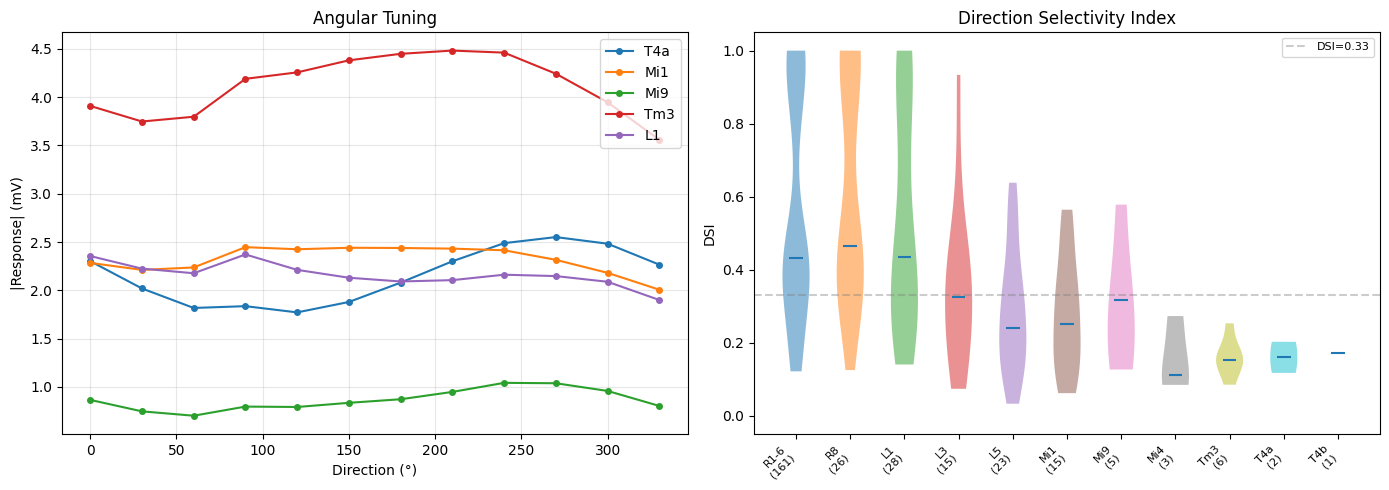

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tuning curves
ax = axes[0]
for ct in ['T4a', 'Mi1', 'Mi9', 'Tm3', 'L1']:
    idx = net.get_indices_by_type(ct)
    if not idx: continue
    mean_r = np.abs(R[:, idx]).mean(axis=1)
    ax.plot(angles, mean_r, 'o-', label=ct, linewidth=1.5, markersize=4)
ax.set_xlabel('Direction (°)'); ax.set_ylabel('|Response| (mV)')
ax.set_title('Angular Tuning'); ax.legend(); ax.grid(alpha=0.3)

# DSI violins
ax = axes[1]
dsi_data, dsi_labels = [], []
for ct in ['R1-6','R8','L1','L3','L5','Mi1','Mi9','Mi4','Tm3','T4a','T4b']:
    idx = net.get_indices_by_type(ct)
    if idx:
        dsi_data.append(DSI[idx])
        dsi_labels.append(f'{ct}\n({len(idx)})')

parts = ax.violinplot(dsi_data, showmedians=True, showextrema=False)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(f'C{i%10}'); pc.set_alpha(0.5)
ax.set_xticks(range(1, len(dsi_labels)+1))
ax.set_xticklabels(dsi_labels, fontsize=8, rotation=45, ha='right')
ax.set_ylabel('DSI'); ax.set_title('Direction Selectivity Index')
ax.set_ylim(-0.05, 1.05)
ax.axhline(0.33, color='gray', ls='--', alpha=0.4, label='DSI=0.33')
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../logs/moving_edge_dsi.png', dpi=150, bbox_inches='tight')
plt.show()

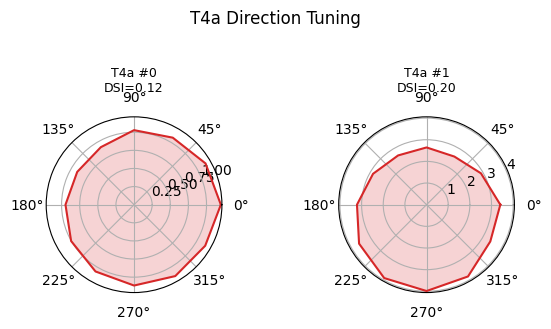

In [9]:
# Polar plots for T4a neurons
t4a_idx = net.get_indices_by_type('T4a')
n_show = min(6, len(t4a_idx))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3),
                             subplot_kw=dict(projection='polar'))
    if n_show == 1: axes = [axes]
    angles_rad = np.deg2rad(angles)
    for ax_i, ni in enumerate(t4a_idx[:n_show]):
        r = np.abs(R[:, ni])
        r_c = np.append(r, r[0])
        th = np.append(angles_rad, angles_rad[0])
        axes[ax_i].plot(th, r_c, 'C3-', linewidth=1.5)
        axes[ax_i].fill(th, r_c, 'C3', alpha=0.2)
        axes[ax_i].set_title(f'T4a #{ax_i}\nDSI={DSI[ni]:.2f}', fontsize=9, y=1.1)
    plt.suptitle('T4a Direction Tuning', fontsize=12, y=1.05)
    plt.tight_layout()
    plt.savefig('../logs/moving_edge_t4a_polar.png', dpi=150, bbox_inches='tight')
    plt.show()